In [1]:
import numpy as np
import pandas as pd
import statsmodels as sm
import seaborn as sns

In [2]:
data= pd.read_csv("C:\\Users\\DELL User\\Desktop\\Decodelabs\\Dataset for Data Analytics(CSV).csv")

In [3]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [4]:
data.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [6]:
data.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
# Missing percentage for all columns
(data.isnull().sum() / len(data)) * 100

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

Handling Missing Data

In [8]:
## UNIQUE COUPON CODES

print(data['CouponCode'].unique())

['SAVE10' 'FREESHIP' nan 'WINTER15']


In [9]:
data['CouponCode'].describe()


count          891
unique           3
top       FREESHIP
freq           313
Name: CouponCode, dtype: object

In [10]:
data['CouponCode'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1200 entries, 0 to 1199
Series name: CouponCode
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 9.5+ KB


In [11]:
## APPLYING LOGIC STRUCTURE THRESHOLD to missing data.
#The missing values are not random. 
#A customer either has a coupon or doesn't
#NaN literally means no coupon was used
# Hence filling the missing data with "NO COUPON USED" is the best way to deal with this variable.
data['CouponCode'] = data['CouponCode'].fillna('NO_COUPON')
print(data['CouponCode'].isnull().sum())

0


In [12]:
#CODE FOR IMPUTING WITH MEAN
# .fillna(mean_value) 
#calculate mean from observed values only
#mean_value = data['Variable'].mean()
#data['Variable'] = data['Variable'].fillna(mean_value)

#CODE FOR IMPUTING WITH MEDIAN
# median_value=data['Variable'].median()
#data['Variable'] = data['Variable'].fillna(median_value)

#USING KNN This is ALSO called Multivariate Imputation — using the joint distribution of all variables to estimate the missing one.


In [13]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO_COUPON,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [14]:
print(data['CouponCode'].isnull().sum())   # Must print 0
print(data['CouponCode'].value_counts())   # 3 codes, total = 1200

0
CouponCode
FREESHIP     313
NO_COUPON    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


ISOLATING ANAOMALIES VIA INTER QUARTILE RANGE 

In [15]:
# IQR = Q3 - Q1
# Lower Bound = Q1 - 1.5 * IQR
# Upper Bound = Q3 + 1.5 * IQR
#Anything outside these bounds = OUTLIER

In [16]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO_COUPON,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [17]:
## we pplot box pots for a 4 features to identify our outliers
import matplotlib.pyplot as plt
import seaborn as sns

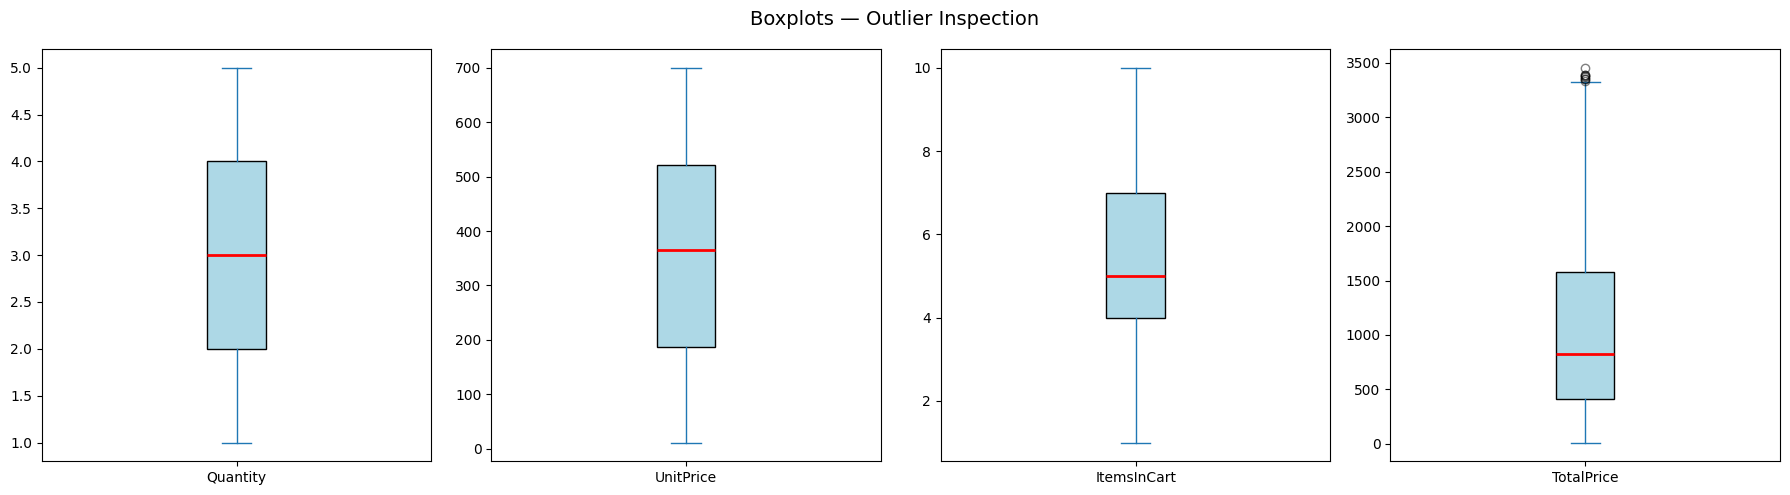

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

data[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].plot(
    kind='box',
    subplots=True,
    ax=axes,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='red', alpha=0.5)  # outliers shown as red dots
)

plt.suptitle("Boxplots — Outlier Inspection", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
data['TotalPrice'].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

In [20]:
Q1  =  410.52  ## 25% value
Q3  = 1578.47 ## 75% value
IQR= Q3-Q1

print('IQR IS', Q3-Q1)


IQR IS 1167.95


In [21]:
LowerBound =  Q1 - (1.5 * IQR)
UpperBound = Q3 + (1.5 * IQR)
print("LowerBound = ", Q1 - (1.5 * IQR))
          
print("UpperBound =", Q3 + (1.5 * IQR))
       
# Any TotalPrice above 3330.40 is an outlier
# Looking at the max = 3456.40 — that's above our upper bound=  3330.3950000000004.. hence outlier detection
# No outliers on the low end since lower bound is negative
# Your mean (1053.97) is higher than your median (823.61) — this confirms right skew, meaning a few high-value orders are pulling the mean up


LowerBound =  -1341.4050000000002
UpperBound = 3330.3950000000004


In [22]:
 # Counting outliers before capping
outliers= data[(data['TotalPrice']<LowerBound)|(data['TotalPrice']>UpperBound )]
outliers
#     outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO_COUPON,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO_COUPON,Facebook,3390.95


In [23]:
##number of outliers
#len(outliers)
outliers.shape[0]
print('number of outlier are',outliers.shape[0])


number of outlier are 8


In [24]:
#Using the Z- score detection method
#Z = (X - mean) / std , X= 3*std + mean
# Calculate the Zscore upper and lower boundary using 3 is the threshold Z score
mean = 1053.97
std  =  819.86
UpperBound_Zscore = 3*std + mean
print('Upper Bound value using Z score is',UpperBound_Zscore)

## thi value of 3513.55 is higher than the upper bound value using IQR, hence not a good meathod of detecting outliers given when the distribution is skewed.
               

Upper Bound value using Z score is 3513.55


In [25]:
Outliers_Zscore=data[(data['TotalPrice']>UpperBound_Zscore)]
Outliers_Zscore ## this catches zero outliers. Confirming the IQR methond is a robust non aparametric way of detecting outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


NEUTRALIZING OUTLIERS

In [26]:
# DELETION METHOD

data_delete=data[data['TotalPrice']< UpperBound] 
data_delete
#data_delete.shape[0]
print("Rows remaining:", data_delete.shape[0])
## reduced rows. Not recommended. it sacrifices adjacent data values
# Before = 1200 rows
# After  = 1192 rows
# Lost   =    8 rows

Rows remaining: 1192


In [27]:
## WINSORIZATION METHOD. WE CLIP VALUES #any value above 3330.40 gets replaced with 3330.40 exactly. No rows lost, just the extreme values capped.
data['TotalPrice']=np.clip(data['TotalPrice'],LowerBound, UpperBound)
data.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.643100
std,1.407557,197.177146,2.281983,818.937626
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3330.395000


EDA

array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
      dtype=object)

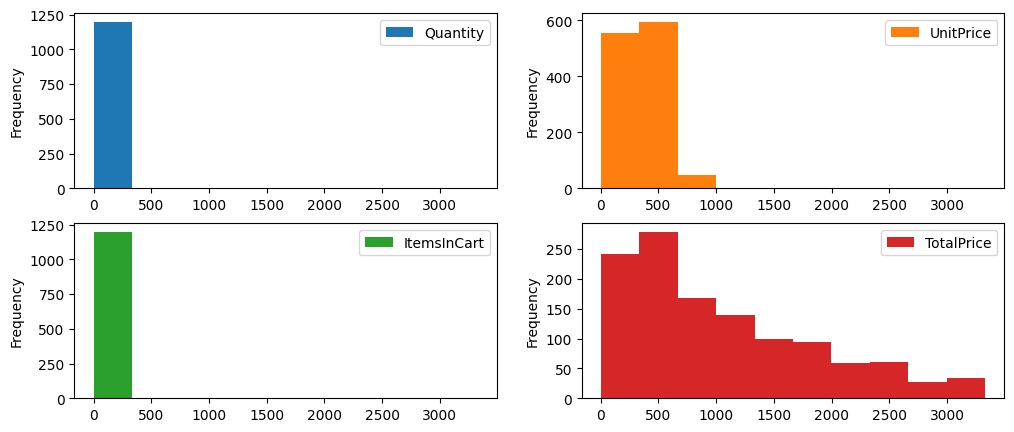

In [28]:
fig, axes= plt.subplots(2,2, figsize=(12,5))

data[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].plot(kind= 'hist',subplots=True, ax=axes)

FEATURE ENGINEERING
1. Discount_Indicator  → from CouponCode (True)
2. Order_Completed     → from OrderStatus
3. Is_Digital_Channel  → from ReferralSource

In [29]:
# Discount_Indicator → did customer use a coupon?

# True = used a coupon    (SAVE10, FREESHIP, WINTER15)
# False = no coupon used   (NO_COUPON)

data['DiscountIndicator'] = (data['CouponCode'] != 'NO_COUPON').astype('bool')

In [30]:
data['OrderStatus'].unique()

array(['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending'],
      dtype=object)

In [31]:
data['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [32]:
# Order_Completed → did order succeed?

# True = Delivered
# False = Cancelled, Pending, Processing, Returned
data['OrderCompleted'] = (data['OrderStatus'] =='Delivered').astype('bool')

In [33]:
data['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [34]:
# Is_Digital_Channel → online vs offline referral?

# Yes = Social Media, Email, Online Ad
# No = Word of Mouth, Direct

data['DigitalRefferals']=(data['ReferralSource']=='Referral').astype('bool')

In [35]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DiscountIndicator,OrderCompleted,DigitalRefferals
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,True,False,False
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,True,False,True
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,True,False,False
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,True,False,False
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,True,False,False
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO_COUPON,Facebook,1325.06,False,False,False
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,True,True,False
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,True,False,False


PHASE TWO

In [36]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DiscountIndicator,OrderCompleted,DigitalRefferals
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,True,False,False
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,True,False,True
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,True,False,False
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,True,False,False
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,True,False,False
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO_COUPON,Facebook,1325.06,False,False,False
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,True,True,False
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,True,False,False


In [37]:
## First consider all categorical variable 
# then consider their counts 
# drop variables with high extreme levels as they can distort the data and destroy model performance

cat_vars1 = ['CustomerID','Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus','TrackingNumber', 'ReferralSource', 'CouponCode']
data[cat_vars1].nunique()



CustomerID         1189
Product               7
ShippingAddress     655
PaymentMethod         5
OrderStatus           5
TrackingNumber     1200
ReferralSource        5
CouponCode            4
dtype: int64

In [38]:
data.value_counts()

OrderID    Date        CustomerID  Product  Quantity  UnitPrice  ShippingAddress  PaymentMethod  OrderStatus  TrackingNumber  ItemsInCart  CouponCode  ReferralSource  TotalPrice  DiscountIndicator  OrderCompleted  DigitalRefferals
ORD201183  2023-04-05  C12607      Desk     1         281.52     460 Main St      Gift Card      Shipped      TRK83653396     6            WINTER15    Referral        281.52      True               False           True                1
ORD201182  2025-06-14  C18473      Chair    2         420.29     700 Main St      Gift Card      Returned     TRK97834202     3            SAVE10      Google          840.58      True               False           False               1
ORD201181  2023-07-27  C70246      Desk     3         158.74     293 Main St      Online         Pending      TRK45708320     7            FREESHIP    Instagram       476.22      True               False           False               1
ORD201180  2023-10-31  C42235      Chair    4         298.36 

CREATING DUMMY VARIABLES FOR CATEGORICAL DATA

In [39]:
## Dropping Customer ID,OrderID, Shipping Address, and tracking number
cat_vars = ['Product',  'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']
data[cat_vars].nunique()


Product           7
PaymentMethod     5
OrderStatus       5
ReferralSource    5
CouponCode        4
dtype: int64

In [40]:
## we encode chosen categorical variables ie. col_vars in the clean_data.
#  Transforming categorical data into dummy variables,  
# using pd.getdummies() tocreates binary columns per category
#drop_first=True   → drops one category per column
data_encoded = pd.get_dummies(data, columns=cat_vars,drop_first=True)
print(data_encoded)

        OrderID        Date CustomerID  Quantity  UnitPrice ShippingAddress  \
0     ORD200000  2023-01-04     C72649         5     570.62     928 Main St   
1     ORD200001  2024-08-23     C75739         2     151.35     823 Main St   
2     ORD200002  2024-02-27     C81728         5     550.68     512 Main St   
3     ORD200003  2023-10-15     C33540         1     273.19     275 Main St   
4     ORD200004  2025-05-08     C81840         4     626.01     668 Main St   
...         ...         ...        ...       ...        ...             ...   
1195  ORD201195  2024-06-20     C21126         1     107.04     392 Main St   
1196  ORD201196  2024-03-04     C20095         2     662.53     778 Main St   
1197  ORD201197  2023-07-13     C79674         2     436.84     275 Main St   
1198  ORD201198  2024-08-22     C64753         4     262.52     509 Main St   
1199  ORD201199  2023-06-11     C57502         4     560.58     201 Main St   

     TrackingNumber  ItemsInCart  TotalPrice  Disco

In [41]:
data_encoded.value_counts()

OrderID    Date        CustomerID  Quantity  UnitPrice  ShippingAddress  TrackingNumber  ItemsInCart  TotalPrice  DiscountIndicator  OrderCompleted  DigitalRefferals  Product_Desk  Product_Laptop  Product_Monitor  Product_Phone  Product_Printer  Product_Tablet  PaymentMethod_Credit Card  PaymentMethod_Debit Card  PaymentMethod_Gift Card  PaymentMethod_Online  OrderStatus_Delivered  OrderStatus_Pending  OrderStatus_Returned  OrderStatus_Shipped  ReferralSource_Facebook  ReferralSource_Google  ReferralSource_Instagram  ReferralSource_Referral  CouponCode_NO_COUPON  CouponCode_SAVE10  CouponCode_WINTER15
ORD201183  2023-04-05  C12607      1         281.52     460 Main St      TRK83653396     6            281.52      True               False           True              True          False           False            False          False            False           False                      False                     True                     False                 False                  False 

CHECKING FOR MULTICOLINEARITY

In [42]:
###  DROPPING THESE FROM THE DATA SET
cols_to_drop = ['ShippingAddress', 'OrderID', 'CustomerID', 'TrackingNumber','Date']

In [43]:
### ERADICATING MULTICOLINEARITY 
# build correlation matrix on numeric columns only using .cor()
#.abs()   → takes absolute value so we catch both positive and negative correlations
Corr_data=data_encoded.drop(columns=cols_to_drop)
corr_matrix = Corr_data.corr().abs()

corr_matrix


,Quantity,UnitPrice,ItemsInCart,TotalPrice,DiscountIndicator,OrderCompleted,DigitalRefferals,Product_Desk,Product_Laptop,Product_Monitor,...,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,CouponCode_NO_COUPON,CouponCode_SAVE10,CouponCode_WINTER15
Quantity,1.000000,0.014553,0.650061,0.615362,0.041636,0.014290,0.035045,0.012244,0.042780,0.000295,...,0.038440,0.066832,0.018314,0.003548,0.005994,0.010120,0.035045,0.041636,0.002074,0.033381
UnitPrice,0.014553,1.000000,0.000602,0.717232,0.036048,0.008777,0.033436,0.055251,0.002695,0.004528,...,0.002048,0.008485,0.018497,0.036862,0.026991,0.005048,0.033436,0.036048,0.001401,0.004009
ItemsInCart,0.650061,0.000602,1.000000,0.392579,0.019329,0.002747,0.018507,0.016291,0.025903,0.012737,...,0.009227,0.025115,0.000898,0.032203,0.019255,0.003894,0.018507,0.019329,0.006611,0.025219
TotalPrice,0.615362,0.717232,0.392579,1.000000,0.007658,0.002534,0.018606,0.034038,0.028297,0.011431,...,0.016914,0.042942,0.003771,0.025905,0.008961,0.005861,0.018606,0.007658,0.007901,0.012433
DiscountIndicator,0.041636,0.036048,0.019329,0.007658,1.000000,0.036169,0.013915,0.015166,0.007881,0.027966,...,0.009706,0.058439,0.016749,0.040273,0.018755,0.026371,0.013915,1.000000,0.329420,0.333956
OrderCompleted,0.014290,0.008777,0.002747,0.002534,0.036169,1.000000,0.052991,0.004394,0.040301,0.002329,...,0.242217,0.248569,0.240943,0.010183,0.012623,0.011008,0.052991,0.036169,0.039414,0.005960
DigitalRefferals,0.035045,0.033436,0.018507,0.018606,0.013915,0.052991,1.000000,0.015079,0.024409,0.007235,...,0.042290,0.008997,0.083959,0.230750,0.238840,0.249955,1.000000,0.013915,0.015565,0.005102
Product_Desk,0.012244,0.055251,0.016291,0.034038,0.015166,0.004394,0.015079,1.000000,0.166741,0.161068,...,0.026562,0.017683,0.001756,0.001828,0.028981,0.025027,0.015079,0.015166,0.030943,0.042513
Product_Laptop,0.042780,0.002695,0.025903,0.028297,0.007881,0.040301,0.024409,0.166741,1.000000,0.162720,...,0.024835,0.019897,0.029169,0.011309,0.010329,0.015344,0.024409,0.007881,0.004278,0.011592
Product_Monitor,0.000295,0.004528,0.012737,0.011431,0.027966,0.002329,0.007235,0.161068,0.162720,1.000000,...,0.019505,0.014734,0.000485,0.037387,0.040895,0.022580,0.007235,0.027966,0.021969,0.024582


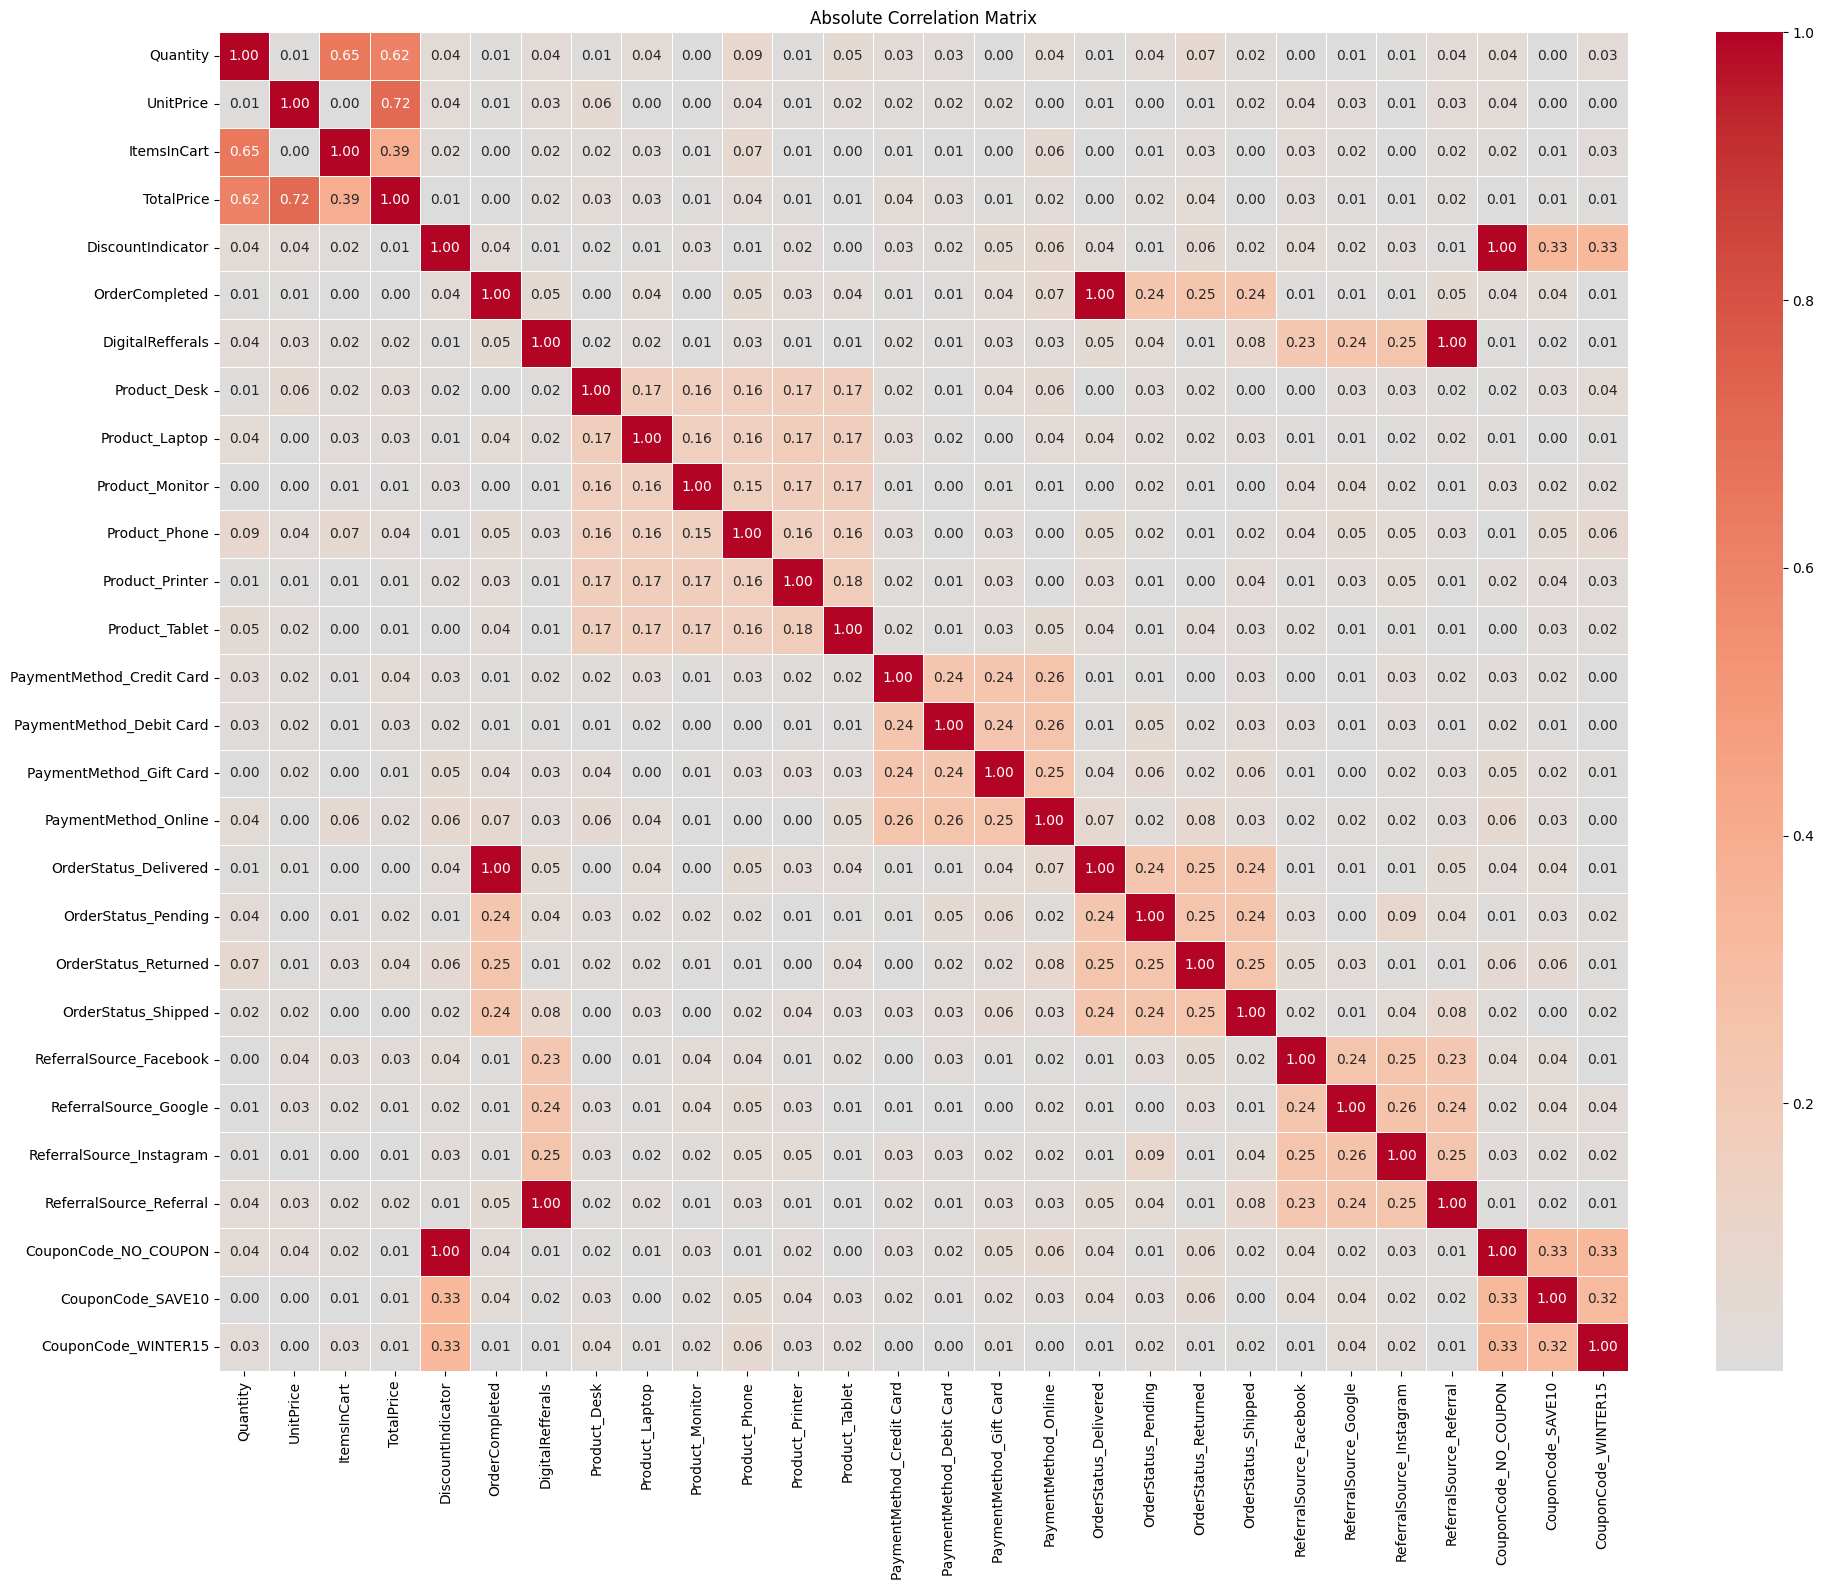

In [44]:
###USING THE HEAT MAP MATRIX
# corr_matrix  → the data we're visualizing
# annot=True   → print the actual correlation 
#                number inside each cell
# fmt='.2f'    → round to 2 decimal places
#                e.g. 0.8234 → 0.82
# cmap='coolwarm' → color scheme:
#                RED   = high correlation (problem!)
#                BLUE  = low correlation (safe!)
# center=0     → makes 0 correlation appear 
#                as neutral white
# linewidths=0.5 → thin lines between cells
#                  for readability

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title("Absolute Correlation Matrix")
plt.tight_layout()
plt.show()


In [45]:
print('No multicollinearity detected')
print('All 26 columns are statistically independent')
print('No columns need to be dropped!')

No multicollinearity detected
All 26 columns are statistically independent
No columns need to be dropped!


STRUCTURAL CONTRACTS AND SCALING

In [46]:
pip install pandera

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
data_encoded.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.643100
std,1.407557,197.177146,2.281983,818.937626
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3330.395000


In [48]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check


# pa               → the main pandera library

# Column           → defines rules for 
#                    a single column

# DataFrameSchema  → combines all column 
#                    rules into one contract

# Check            → the actual statistical 
#                    rule being enforced
#                    e.g. value must be > 0


# DataFrameSchema  → the full contract
# Column           → one clause in the contract
# Check            → the condition of that clause



In [49]:
import pandera.pandas as pa
from pandera.pandas import Column, DataFrameSchema, Check

In [50]:

Schema= DataFrameSchema({'Quantity': Column(int,Check.greater_than(0)),
                         'UnitPrice': Column(float,Check.greater_than(0)),
                         'ItemsInCart': Column(int, Check.greater_than(0)),
                         'TotalPrice': Column(float,[Check.greater_than(0), Check.less_than_or_equal_to(3330.40)])})

#Why TotalPrice Has Two Checks
# Check.greater_than(0),          # lower boundary
# Check.less_than_or_equal_to(3330.40)  # upper boundary
#                                       # our IQR bound!

In [51]:
print(Schema)

<Schema DataFrameSchema(
    columns={
        'Quantity': <Schema Column(name=Quantity, type=DataType(int64))>
        'UnitPrice': <Schema Column(name=UnitPrice, type=DataType(float64))>
        'ItemsInCart': <Schema Column(name=ItemsInCart, type=DataType(int64))>
        'TotalPrice': <Schema Column(name=TotalPrice, type=DataType(float64))>
    },
    checks=[],
    parsers=[],
    coerce=False,
    dtype=None,
    index=None,
    strict=False,
    name=None,
    ordered=False,
    unique_column_names=False,
    metadata=None, 
    add_missing_columns=False
)>


In [52]:
# Assume try/except as HYPOTHESIS TEST:

# H0 (null)       → data meets all contracts
# H1 (alternative)→ data violates contracts

# Yes! = fail to reject H0 → data is clean
# No! = reject H0  → violations exist
# pa.errors.SchemaErrors → the specific type of error pandera raises when rules are violated
# err → stores all violation details
# err.failure_cases → a dataframe showing: which column failed which row failed what the actual value was
try:
    Schema.validate(data_encoded,lazy=True)
    print(' YES!All validations passed! Data is clean')
    print('Data meets all statistical contracts')
except pa.errors.SchemaErrors as err:
    print(' NO! Schema violations found')   
    print( err.failure_cases)

 YES!All validations passed! Data is clean
Data meets all statistical contracts
